In [1]:
import pandas as pd

df = pd.read_csv("Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
print(df.shape)

(891, 12)


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Improve plot appearance
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

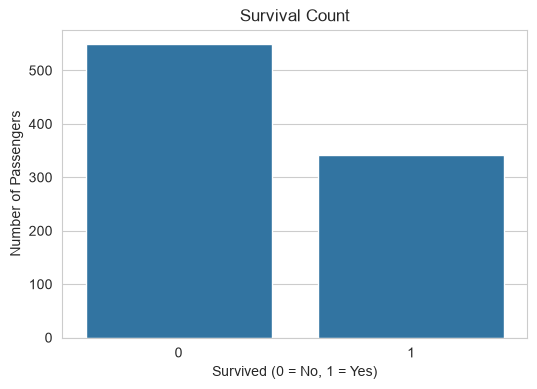

In [7]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Survived", data=df)

plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

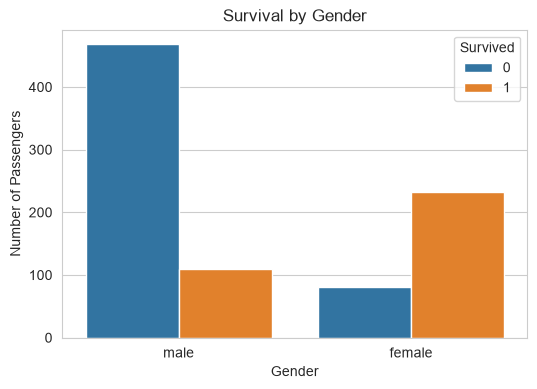

In [8]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Sex", hue="Survived", data=df)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

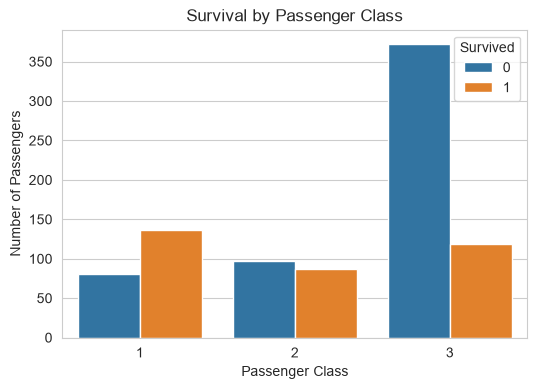

In [9]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Pclass", hue="Survived", data=df)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

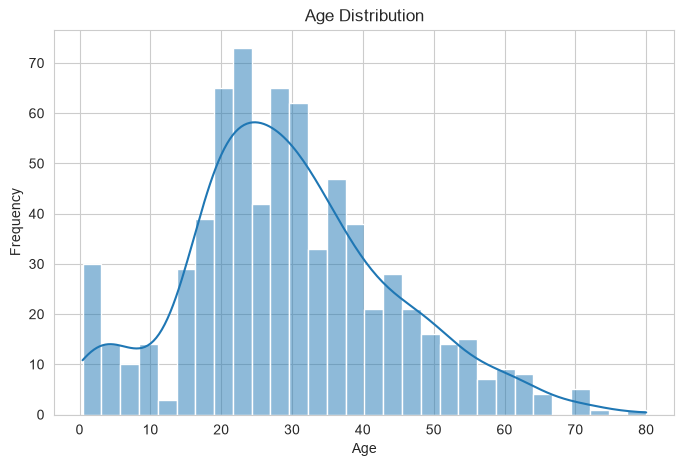

In [10]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Age"], bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

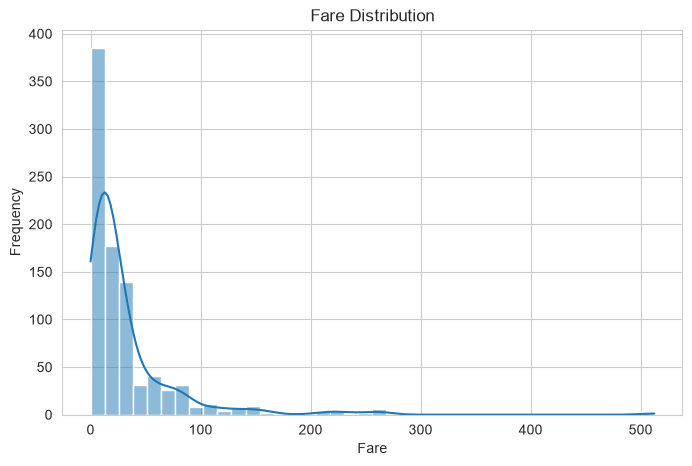

In [11]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Fare"], bins=40, kde=True)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.show()

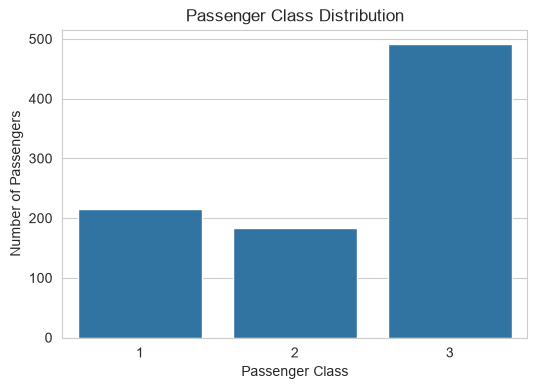

In [12]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Pclass", data=df)

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

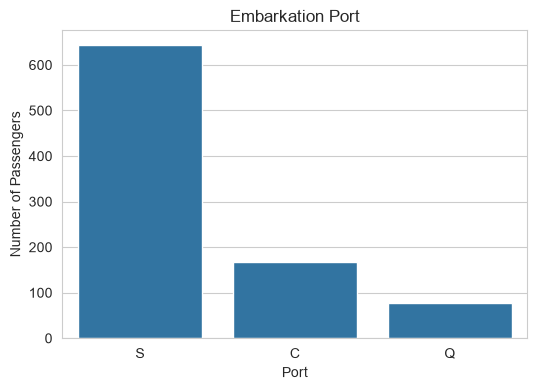

In [13]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Embarked", data=df)

plt.title("Embarkation Port")
plt.xlabel("Port")
plt.ylabel("Number of Passengers")

plt.show()

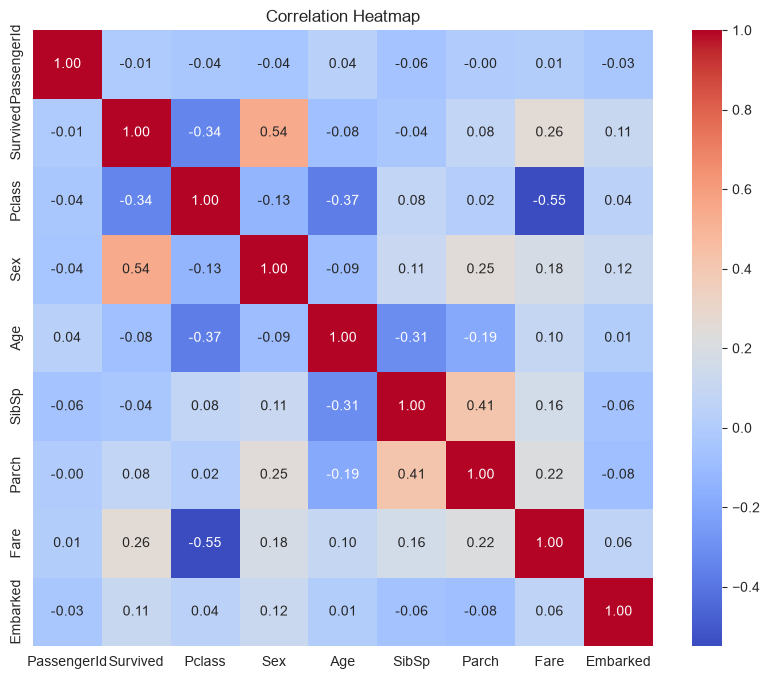

In [14]:
temp_df = df.copy()

temp_df["Sex"] = temp_df["Sex"].map({"male": 0, "female": 1})
temp_df["Embarked"] = temp_df["Embarked"].map({"S": 0, "C": 1, "Q": 2})

plt.figure(figsize=(10, 8))

sns.heatmap(
    temp_df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

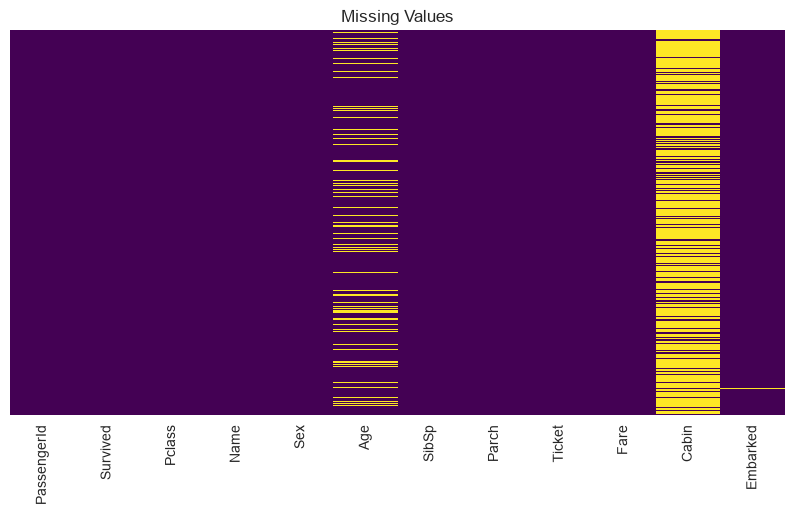

In [15]:
plt.figure(figsize=(10, 5))

sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")

plt.title("Missing Values")

plt.show()

In [16]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [17]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [18]:
df["Age"].isnull().sum()

np.int64(0)

In [19]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [20]:
df.drop("Cabin", axis=1, inplace=True)

In [21]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='str')

In [22]:
df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

In [23]:
df["Sex"].head()

0    0
1    1
2    1
3    1
4    0
Name: Sex, dtype: int64

In [24]:
df["Embarked"] = df["Embarked"].map({
    "S": 0,
    "C": 1,
    "Q": 2
})

In [25]:
df["Embarked"].unique()

array([0, 1, 2])

In [26]:
df.drop(
    ["PassengerId", "Name", "Ticket"],
    axis=1,
    inplace=True
)

In [27]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.8 KB


In [29]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [30]:
X = df.drop("Survived", axis=1)

y = df["Survived"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (891, 7)
Target Shape: (891,)


Train-Test Split & Model Training

In [31]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [33]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (712, 7)
Testing Features  : (179, 7)
Training Labels   : (712,)
Testing Labels    : (179,)


In [34]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

log_accuracy = accuracy_score(y_test, log_pred)

print("Logistic Regression Accuracy:", round(log_accuracy * 100, 2), "%")

Logistic Regression Accuracy: 80.45 %


In [35]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", round(dt_accuracy * 100, 2), "%")

Decision Tree Accuracy: 82.12 %


In [36]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")

Random Forest Accuracy: 81.56 %


In [37]:
results = {
    "Logistic Regression": log_accuracy,
    "Decision Tree": dt_accuracy,
    "Random Forest": rf_accuracy
}

for model, score in results.items():
    print(f"{model:<22}: {score*100:.2f}%")

Logistic Regression   : 80.45%
Decision Tree         : 82.12%
Random Forest         : 81.56%


In [38]:
best_model = max(results, key=results.get)

print("Best Model :", best_model)
print("Accuracy   :", round(results[best_model]*100, 2), "%")

Best Model : Decision Tree
Accuracy   : 82.12 %


Model Evaluation

In [39]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
cm = confusion_matrix(y_test, dt_pred)

print(cm)

[[97 13]
 [19 50]]


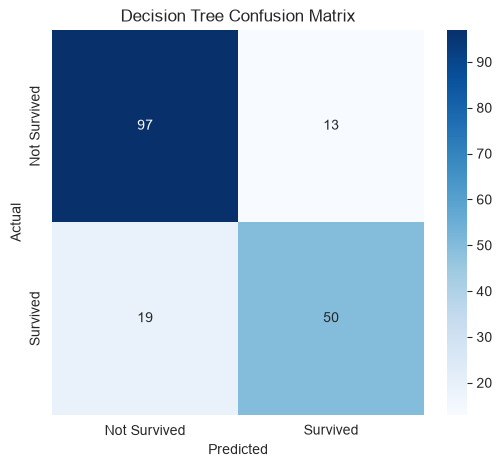

In [41]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Survived", "Survived"],
    yticklabels=["Not Survived", "Survived"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

In [42]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       110
           1       0.79      0.72      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



In [43]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

    Feature  Importance
1       Sex    0.316638
2       Age    0.270281
5      Fare    0.232792
0    Pclass    0.110281
6  Embarked    0.034104
3     SibSp    0.019053
4     Parch    0.016851


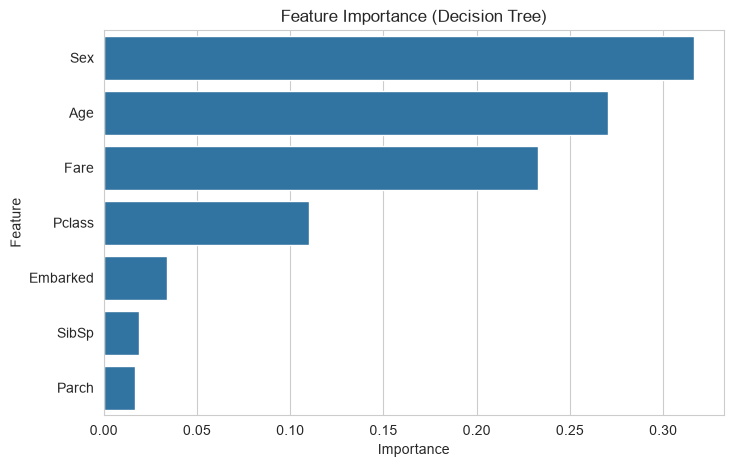

In [44]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance (Decision Tree)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [45]:
new_passenger = pd.DataFrame({
    "Pclass": [1],
    "Sex": [1],          # Female
    "Age": [30],
    "SibSp": [1],
    "Parch": [0],
    "Fare": [80],
    "Embarked": [1]      # Cherbourg
})

prediction = dt_model.predict(new_passenger)

if prediction[0] == 1:
    print("Prediction: Passenger Survived")
else:
    print("Prediction: Passenger Did Not Survive")

Prediction: Passenger Survived


In [46]:
new_passenger = pd.DataFrame({
    "Pclass": [3],
    "Sex": [0],          # Male
    "Age": [25],
    "SibSp": [0],
    "Parch": [0],
    "Fare": [7.25],
    "Embarked": [0]      # Southampton
})

prediction = dt_model.predict(new_passenger)

if prediction[0] == 1:
    print("Prediction: Passenger Survived")
else:
    print("Prediction: Passenger Did Not Survive")

Prediction: Passenger Did Not Survive


In [47]:
import joblib

joblib.dump(dt_model, "titanic_decision_tree_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [48]:
loaded_model = joblib.load("titanic_decision_tree_model.pkl")

Hyperparameter Tuning & Cross-Validation

In [49]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

In [50]:
print("Current Decision Tree Accuracy:", round(dt_accuracy * 100, 2), "%")

Current Decision Tree Accuracy: 82.12 %


In [51]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [52]:
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",Tru

In [53]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 10}


In [54]:
print("Best Cross Validation Accuracy:",
      round(grid_search.best_score_ * 100, 2), "%")

Best Cross Validation Accuracy: 82.17 %


In [55]:
best_dt = grid_search.best_estimator_

best_pred = best_dt.predict(X_test)

best_accuracy = accuracy_score(y_test, best_pred)

print("Optimized Decision Tree Accuracy:",
      round(best_accuracy * 100, 2), "%")

Optimized Decision Tree Accuracy: 79.89 %


In [56]:
print("Original Decision Tree :", round(dt_accuracy * 100, 2), "%")
print("Optimized Decision Tree:", round(best_accuracy * 100, 2), "%")

Original Decision Tree : 82.12 %
Optimized Decision Tree: 79.89 %


In [57]:
scores = cross_val_score(
    best_dt,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:")
print(scores)

Cross Validation Scores:
[0.79888268 0.81460674 0.82022472 0.78651685 0.84831461]


In [58]:
print("Average Accuracy:",
      round(scores.mean() * 100, 2), "%")

print("Standard Deviation:",
      round(scores.std() * 100, 2), "%")

Average Accuracy: 81.37 %
Standard Deviation: 2.1 %


In [59]:
import joblib

joblib.dump(best_dt, "optimized_titanic_model.pkl")

print("Optimized model saved successfully!")

Optimized model saved successfully!


In [60]:
loaded_model = joblib.load("optimized_titanic_model.pkl")